In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [3]:
train_data = pd.read_csv("./input/train.csv")
test_data= pd.read_csv("./input/test.csv")
train_labels=np.array(train_data.loc[:,'label'])
train_data=np.array(train_data.loc[:,train_data.columns!='label'])

train_data = train_data.reshape(42000, 784)

Y = np.zeros(shape=(42000,10))

for i in range(len(Y)):
    Y[i][train_labels[i]] = 1

In [4]:
def sigmoid(Z):
    A = 1/(1+np.exp(-Z))
    return A

def softmax(Z):
    Ztransform = Z - np.max(Z, axis = 1, keepdims=True)
    A = np.exp(Ztransform)/(np.sum(np.exp(Ztransform), axis = 1, keepdims=True))
    return A

def cost(Y, A):
    return (-1/len(Y))* np.sum(Y * np.log(A))

In [5]:
def forwardprop(X, weights, biases):
    Zcache = []
    Acache = []

    A = X

    for i in range(len(weights)):
        
        Z = A @ weights[i] + biases[i]
        Zcache.append(Z)

        if i == len(weights)-1:
            A = softmax(Z)
        else:
            A = sigmoid(Z)

        Acache.append(A)

    return A, Zcache, Acache

In [6]:
def backprop(weights, Acache, X, Y):
    m = len(Y)
    dZ = Acache[-1]-Y
    dW = []
    db = []

    for i in range(len(weights)-1, -1, -1):
        if i == 0:
            A_prev = X
        else:
            A_prev = Acache[i-1]
        dWi = 1/(m) * np.transpose(A_prev) @ dZ
        dW.append(dWi)
        dbi = 1/(m) * np.sum(dZ, axis=0, keepdims=True)
        db.append(dbi)
        if i > 0:
            dA = dZ @ np.transpose(weights[i])
            dZ = dA*(Acache[i-1]*(1-Acache[i-1]))
    dW = list(reversed(dW))
    db = list(reversed(db))
    return dW, db


In [22]:
def update_parameters(weights, biases, dW, db, alpha):
    for i in range(len(weights)):
        weights[i] = weights[i] - alpha*dW[i]
    for i in range(len(biases)):
        biases[i] = biases[i] - alpha*db[i]
    return weights, biases

In [23]:
layers = [784, 128, 10]

weights = []
biases = []

for i in range(len(layers)-1):
    weight = np.random.normal(loc = 0, scale = (layers[i])**(-0.5), size=[layers[i], layers[i+1]])
    weights.append(weight)
    bias = np.zeros(shape=[1,layers[i+1]])
    biases.append(bias)

In [24]:
A, Zcache, Acache = forwardprop(train_data, weights, biases)
dW, db = backprop(weights=weights, Acache=Acache, X=train_data, Y=Y)

In [25]:
alpha = 0.05
n = 100
costs = []
iterations = []
for j in range(n):
    A, Zcache, Acache = forwardprop(train_data, weights, biases)
    J = cost(Y, A)
    costs.append(J)
    iterations.append(j)
    dW, db = backprop(weights=weights, Acache=Acache, X=train_data, Y=Y)
    weights, biases = update_parameters(weights, biases, dW, db, alpha)


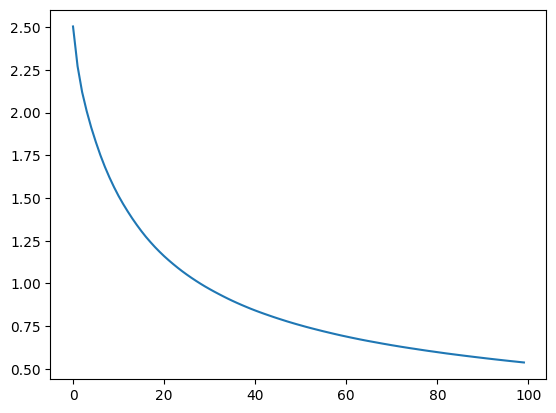

In [26]:
plt.plot(iterations, costs)
plt.show()